## Homework 1 - Phase I & II Analysis Using Shewhart $\bar{X}$ and R/s Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: September 19, 2026 via D2L**

## Instructions:

A company called Blue Ridge Filament Co (BRFC) manufactures 1.75 mm PLA filament for 3D printers, selling to both hobbyist and small-manufacturing customers. Over the last quarter, customer support tickets describing clogging, stringing, and inconsistent print layers have risen sharply, and BRFC recently lost a wholesale account to a competitor over “inconsistent quality.” The plant manager has asked your quality control team to investigate Extruder Line 3, the line most frequently named in the complaint data, and to determine whether the line is running in a state of statistical control. This line is about six months away from needing its heating element replaced, but it could be replaced sooner if necessary.

The plant manager is particularly interested in the filament diameter produced (mm), measured inline by a laser micrometer as each spool is produced. Diameter that runs too thin causes under-extrusion and stringing; diameter that runs too thick causes jams and clogs in customers' print heads. Filament diameter is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of production data from Line 3: 5 spools sampled at random each week, for 25 consecutive weeks. After validating statistical control and process capability, the team can establish an ongoing monitoring plan for Phase II analysis.

## Key Specifications

| Quantity | Value |
|---|---|
| Target diameter | 1.750 mm |
| Lower Specification Limit (LSL) | 1.700 mm |
| Upper Specification Limit (USL) | 1.800 mm |
| Subgroup size (n) | 5 spools per week |
| Phase I subgroups (m) | 25 weeks |
| Phase II subgroups | 20 weeks |

In [3]:
## Clone your forked repository to Colab ##

## Specify your GitHub username:
user_name <- "wasifmostofa36"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}
## Set working drive to today's lecture:

setwd("STAT-7110-Quality-Control//Assignments//HW1")

## Define & Measure

### Q1: Briefly describe the purpose of this analysis



The plant manager has asked the quality control team to investigate Extruder Line 3, and to determine whether the line is running in a state of statistical control. The plant manager is particularly interested in the filament diameter produced (mm), measured inline by a laser micrometer as each spool is produced.

The purpose of the analysis is to determinewhether the line is running in a state of statistical control.

### Q2: Identify the quality characteristic your team will monitor, classify its units and measurement scale.


The quality characteristic that our team will be monitoring is the filament diameter produced (mm)

### Q3: Briefly describe why a Shewhart $\bar{X}$ and $R/s$ chart would be appropriate in this scenario. What are its limitations?

We are monitoring a continous variable where we want to determine the Process location (is the mean staying where it should be) and the Process variability ( is the spread of the process staying stable)

## Analyze

### Q4: Read the Phase I data into R. Calculate and report the estimated process mean and standard deviation using both the $R$ and $s$ methods.

Rows: 25
Columns: 6
$ Subgroup <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18…
$ Meas1    <dbl> 1.759712, 1.752064, 1.755094, 1.763434, 1.751915, 1.746336, 1…
$ Meas2    <dbl> 1.742690, 1.733264, 1.745186, 1.746130, 1.757228, 1.769405, 1…
$ Meas3    <dbl> 1.771452, 1.767347, 1.753372, 1.747787, 1.745419, 1.752795, 1…
$ Meas4    <dbl> 1.758564, 1.761277, 1.763998, 1.747608, 1.755608, 1.750858, 1…
$ Meas5    <dbl> 1.755669, 1.744550, 1.745075, 1.748262, 1.742620, 1.737254, 1…


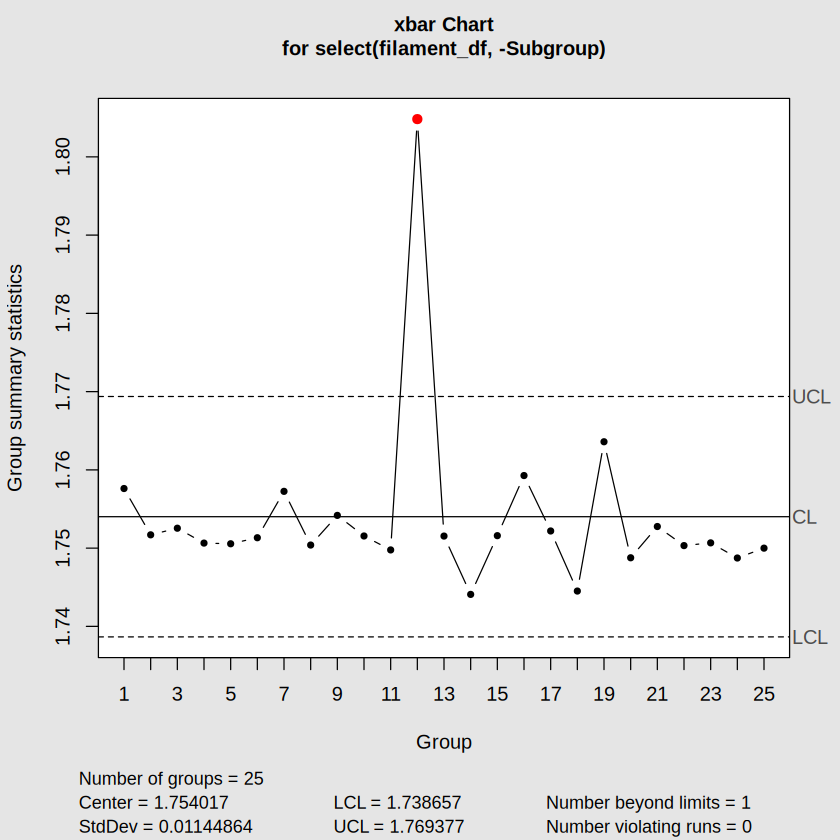

In [9]:
## Q4 Code ##
## Install tidyverse, readxl, and qcc packages if necessary ##

#install.packages(c("tidyverse", "readxl", "qcc"))

## Load the libraries ##

library(tidyverse)
library(readxl)
library(qcc)

## Read in the Wafer Data ##

filament_df <- read_excel("FilamentDiameter_PhaseI.xlsx")

## Data Integrity Check ##

filament_df |>
  glimpse()

## These data are organized in "wide format"
## where each row represents a point in time
## rather than a unique observation.
## For the qcc package, wide data is typically
## what we need. ##

## Save and plot phase 1 xbar chart ##

phase1_xbar <- qcc(filament_df |> select(-`Subgroup`),
                   type = "xbar",
                   plot = TRUE)

Subplot 12 was flagged on the X chart. It was above the UCL.

### Interpreting the Phase I $\bar{X}$-Chart

From this chart we can read off the key Phase I estimates directly:

| Output | Value |
|---|---|
| Number of groups | $m = 25$ |
| Center ($\bar{\bar{x}}$) | $1.75$ |
| Std. Dev. ($\hat{\sigma}$) | $0.011$ |
| LCL | $1.74$ |
| UCL | $1.77$ |


Let's now examine the Phase 1 R Chart:

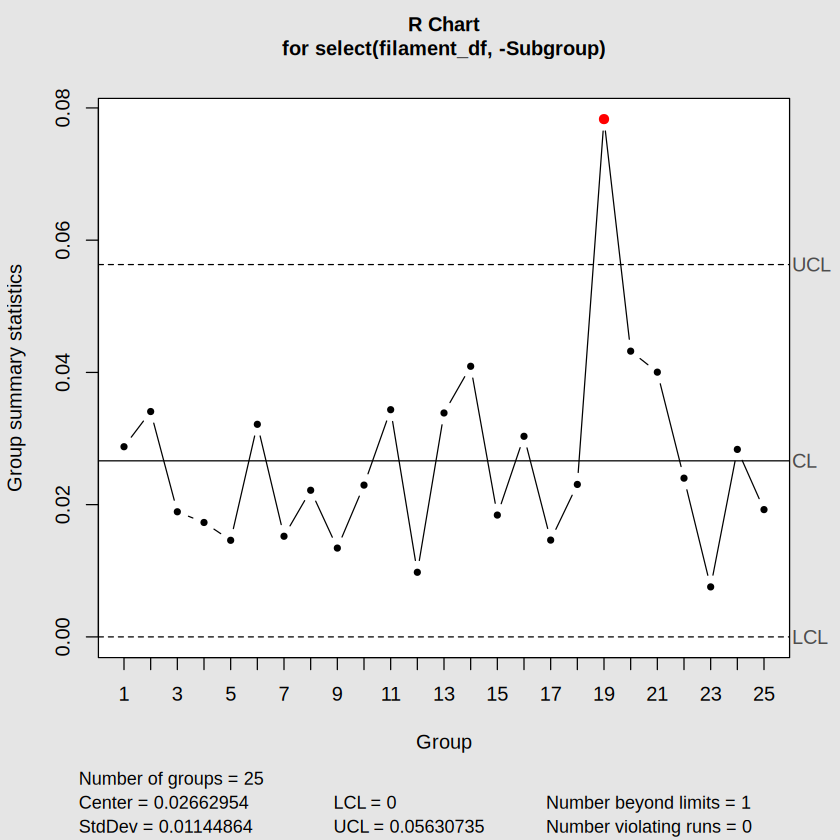

In [10]:
#Using R Method
phase1_r <- qcc(filament_df |> select(-`Subgroup`),
                 type = "R",
                 plot = TRUE)

List of 11
 $ call      : language qcc(data = filament_df[, -1], type = "S", plot = TRUE)
 $ type      : chr "S"
 $ data.name : chr "filament_df[, -1]"
 $ data      : num [1:25, 1:5] 1.76 1.75 1.76 1.76 1.75 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:25] 0.01029 0.01349 0.00788 0.00719 0.00635 ...
  ..- attr(*, "names")= chr [1:25] "1" "2" "3" "4" ...
 $ sizes     : int [1:25] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 0.0109
 $ std.dev   : num 0.0115
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 0 0.0227
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

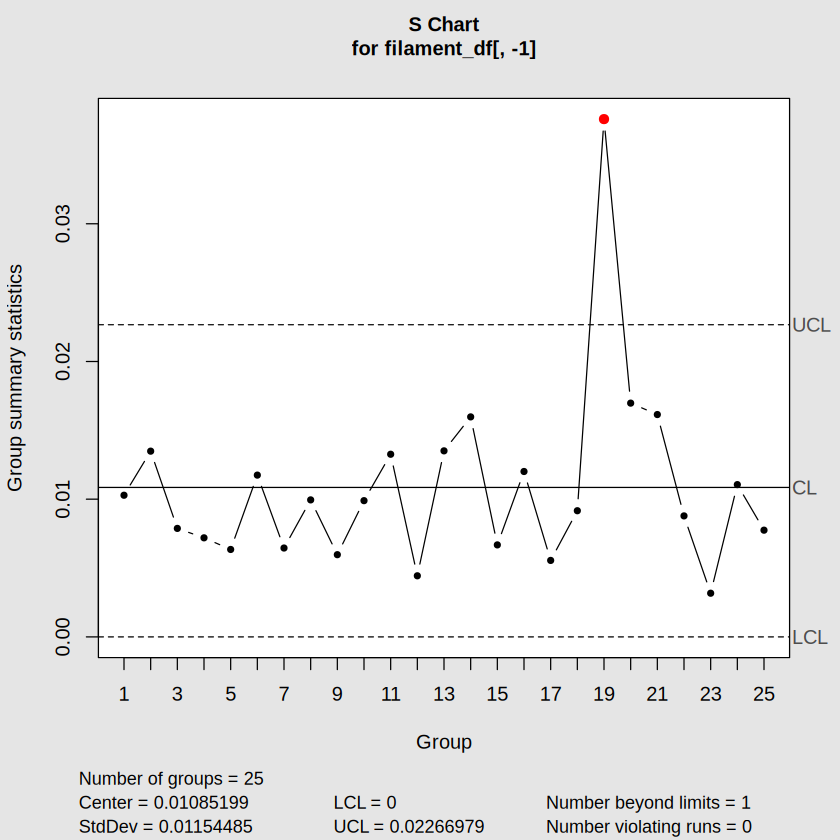

In [12]:
###Using the S Method

qcc(filament_df[,-1],type="S",plot=TRUE)

###Using the R method
###Interpreting the Phase 1 R-Chart

From this chart we can read off the key Phase I estimates directly:

Process Mean (from X Chart): 1.754
Std. Deviation: .011

###Using the S method

From the S chart directly,
Process Mean (from X Chart): 1.754
Std. Deviation: .011




### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

From this chart we can read off the key Phase I estimates directly:

| Output | Value |
|---|---|
| Number of groups | $m = 25$ |
| Center ($\bar{\bar{x}}$) | $0.02663$ |
| Std. Dev. ($\hat{\sigma}$) | $0.0114$ |
| LCL | $0$ |
| UCL | $0.0563$ |

\begin{align*}
\hat{\mu}_0 &= \bar{\bar{x}} = 1.505 \\
\hat{\sigma}_0 &= \frac{\bar{R}}{d_2} = \frac{0.02663}{2.326} \\
&\approx 0.0114
\end{align*}

There is one point (Subgroup 19) that is beyond the limits from the R chart. Also, Subgroup 12 from the X chart was beyond the limits. There are no violating runs.

Based on this, this indicates that the chart is not showing statistical control. Subgroup 19 is above the upper control limit. As for a contextual explanation as to why these OOC points may have been obseved, it may be possible that the heating element is reaching its end of life period, since the prompt mentioned that there isa  6 month lifespan (or sooner) for the element.

For replotting, since Subgroup 12 is not out of control in the R chart we will keep 12 but omit 19.


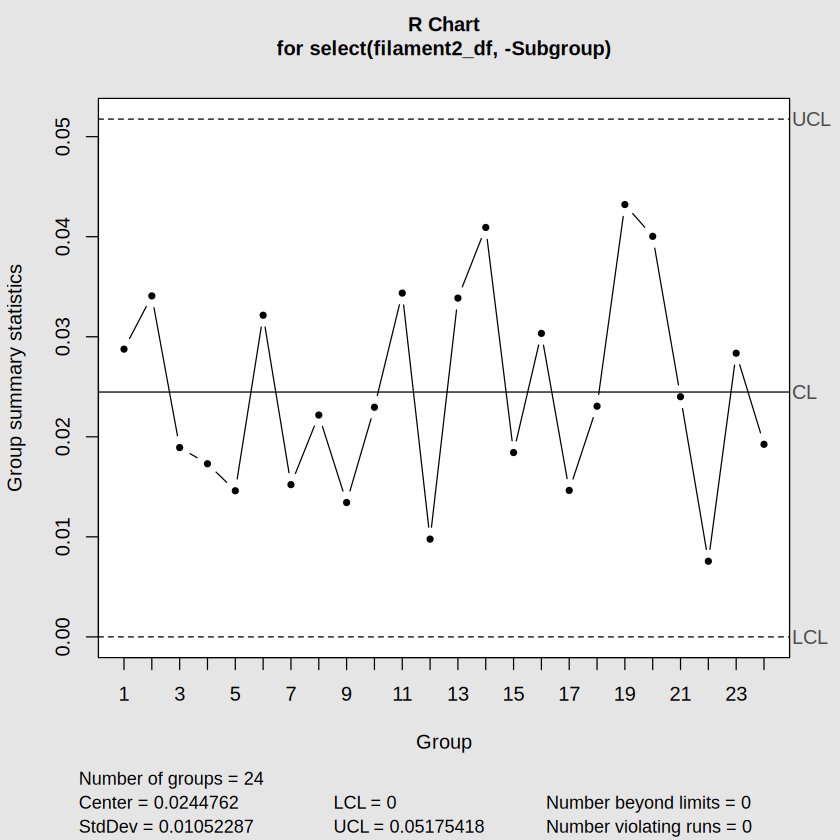

In [13]:
## Q5 Code ##
#omit subplot 19 from the chart
filament2_df <- filament_df |>
  filter(!`Subgroup` == 19)


phase1_r2 <- qcc(filament2_df |> select(-`Subgroup`),
                 type = "R",
                 plot = TRUE)

### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

$beyond.limits
[1] 12

$violating.runs
[1] 23 24

[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 20 21 22 23 24 25

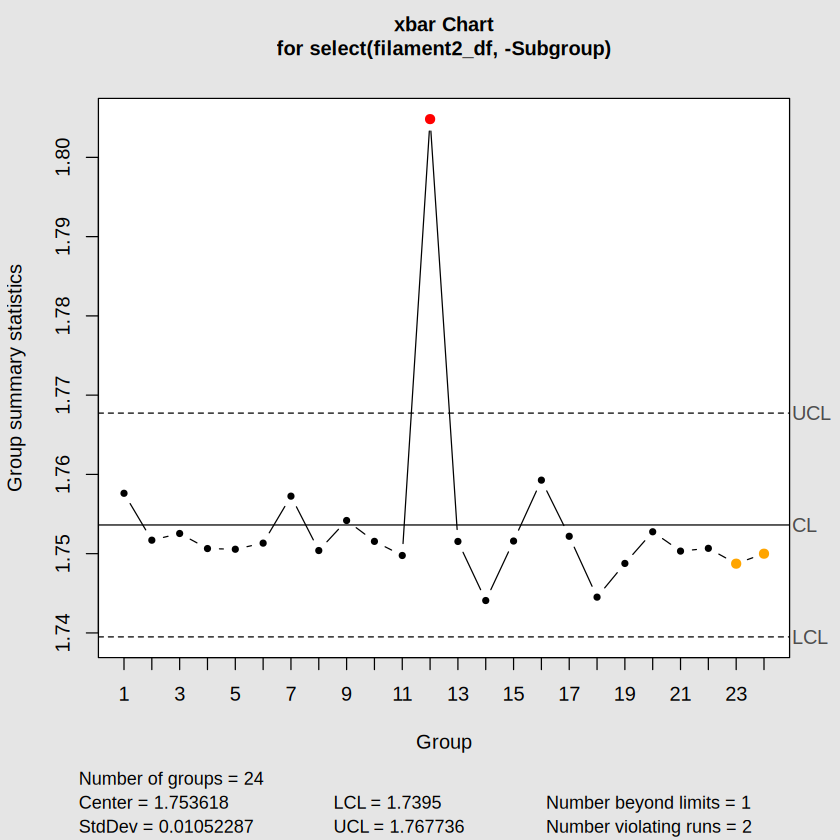

In [17]:
## Q6 Code ##
phase1_xbar2 <- qcc(filament2_df |> select(-`Subgroup`),
                   type = "xbar",
                   plot = TRUE)

phase1_xbar2$violations
filament2_df$Subgroup

1.   **Does the chart show evidence of statistical control?** No it does not
2.  **If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.** Subgroup 12 beyond the UCL, and subgroups 24 and 25 were flagged as a violating run

$beyond.limits
integer(0)

$violating.runs
numeric(0)

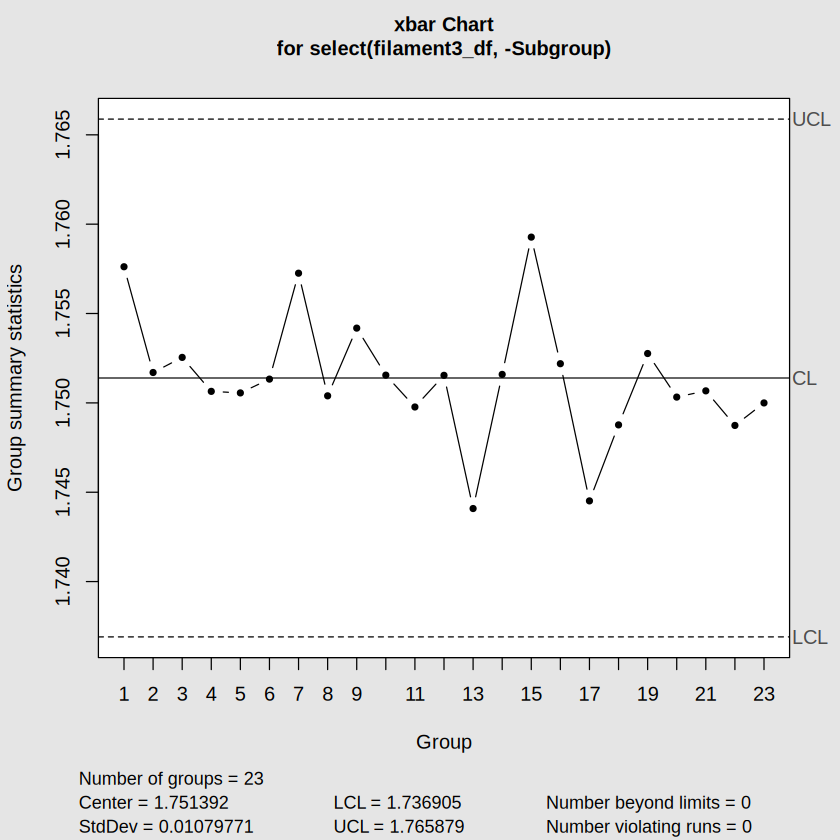

In [18]:
# will remove subplot 12 and replot
filament3_df <- filament2_df |>
  filter(!Subgroup == 12)

phase1_xbar3 <- qcc(filament3_df |> select(-`Subgroup`),
                    type = "xbar",
                    plot = TRUE)

phase1_xbar3$violations

### Q7: Repeat the same process in Q4 - Q6 now using the $s$ chart instead of the $R$ chart

$beyond.limits
[1] 19

$violating.runs
numeric(0)

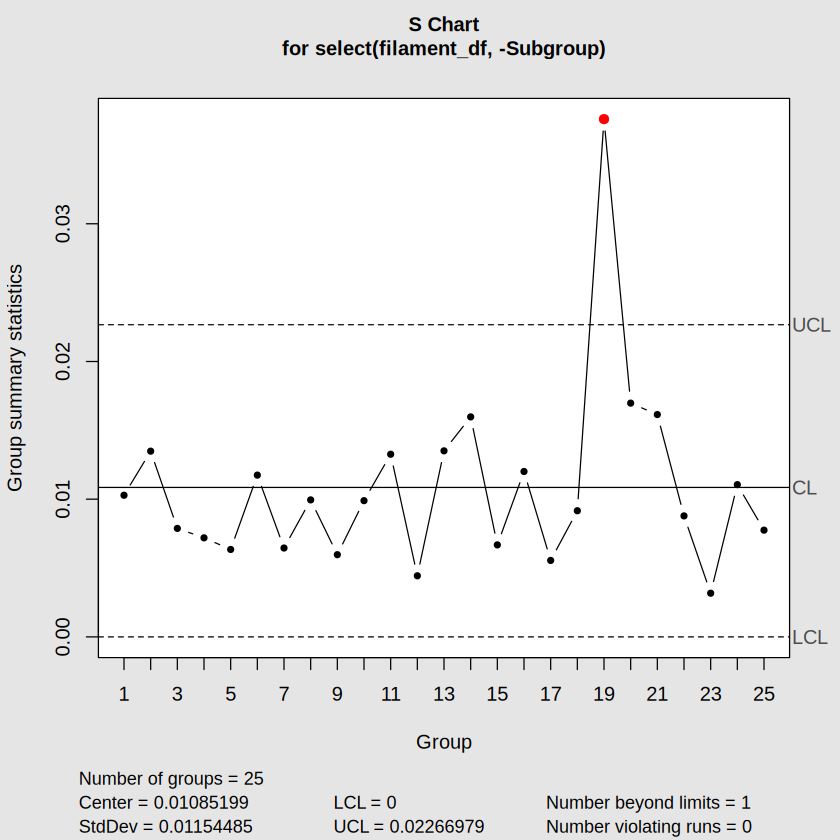

In [19]:
## Q7 Code ##

## Phase I s chart, all 25 subgroups ##

phase1_s <- qcc(filament_df |> select(-`Subgroup`),
                type = "S",
                plot = TRUE)

phase1_s$violations

$beyond.limits
integer(0)

$violating.runs
numeric(0)

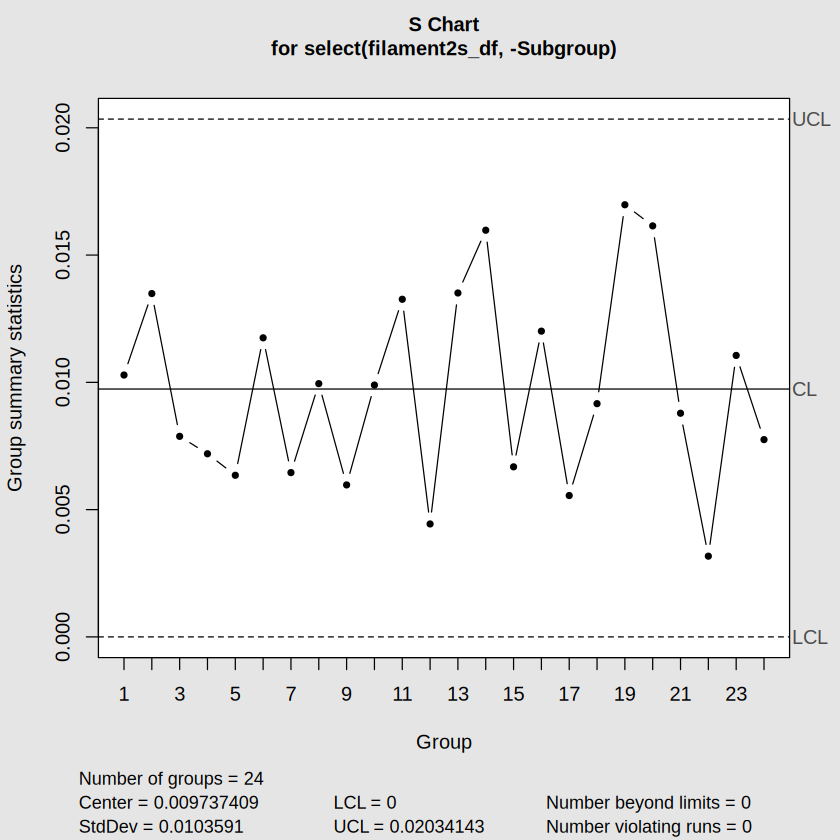

In [20]:
#Subgroup 19 was flagged again, so will need to omit and replot again
## Omit subgroup 19 and replot ##

filament2s_df <- filament_df |>
  filter(!Subgroup == 19)

phase1_s2 <- qcc(filament2s_df |> select(-`Subgroup`),
                 type = "S",
                 plot = TRUE)

phase1_s2$violations

$beyond.limits
[1] 12

$violating.runs
[1] 23 24

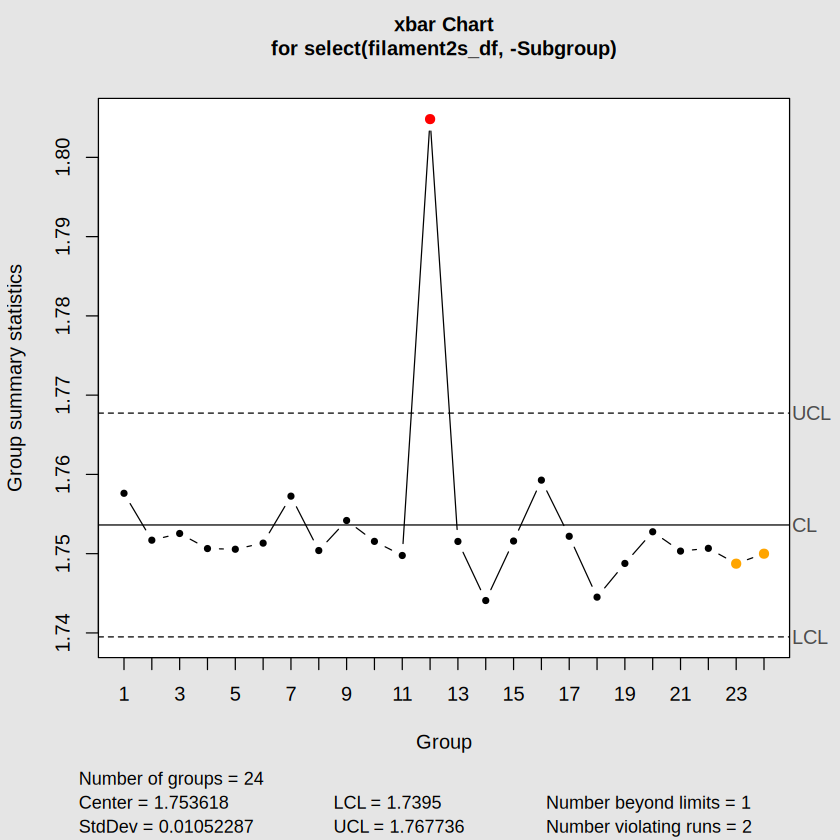

In [27]:
#XBar Chart using S

sig_hat_s <- sd.xbar(filament2s_df[,-1]) # This gives us s-bar/c4

phase1_xbar2s <- qcc(filament2s_df |> select(-`Subgroup`),type="xbar",std.dev=sig_hat_s,plot=TRUE)
phase1_xbar2s$violations
#will omit subgroup 12

$beyond.limits
integer(0)

$violating.runs
numeric(0)

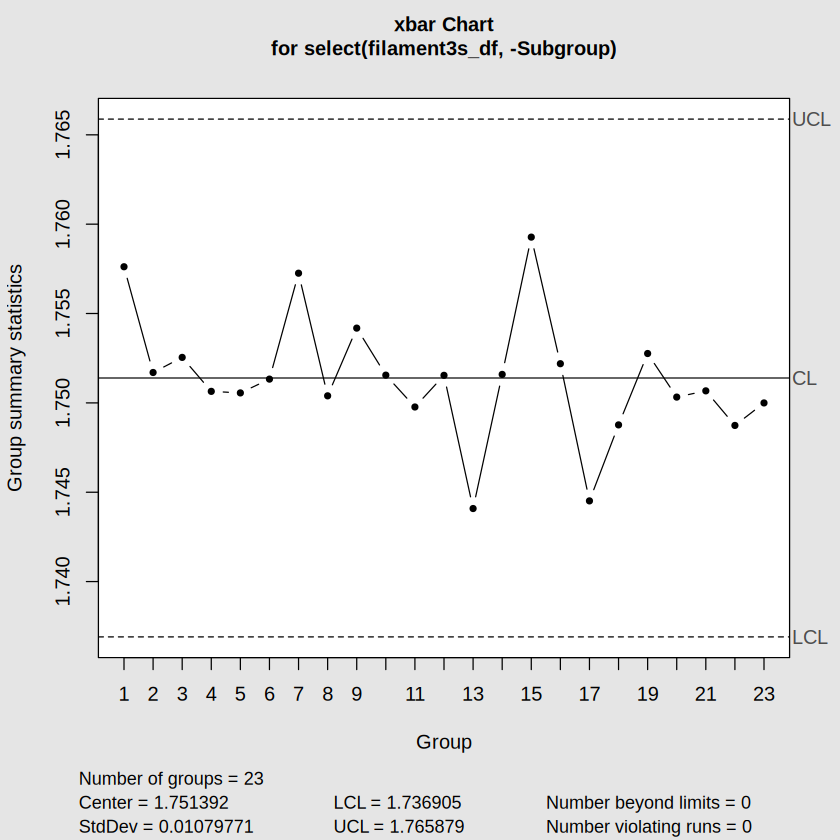

In [28]:
filament3s_df <- filament2s_df |>
  filter(!Subgroup == 12)

phase1_xbar3s <- qcc(filament3s_df |> select(-`Subgroup`),
                    type = "xbar",
                    std.dev = sd.xbar(filament3s_df[,-1]),
                    plot = TRUE)

phase1_xbar3s$violations

List of 11
 $ call      : language qcc(data = select(filament3s_df, -Subgroup), type = "S", plot = TRUE)
 $ type      : chr "S"
 $ data.name : chr "select(filament3s_df, -Subgroup)"
 $ data      : num [1:23, 1:5] 1.76 1.75 1.76 1.76 1.75 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:23] 0.01029 0.01349 0.00788 0.00719 0.00635 ...
  ..- attr(*, "names")= chr [1:23] "1" "2" "3" "4" ...
 $ sizes     : int [1:23] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 0.00997
 $ std.dev   : num 0.0106
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 0 0.0208
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

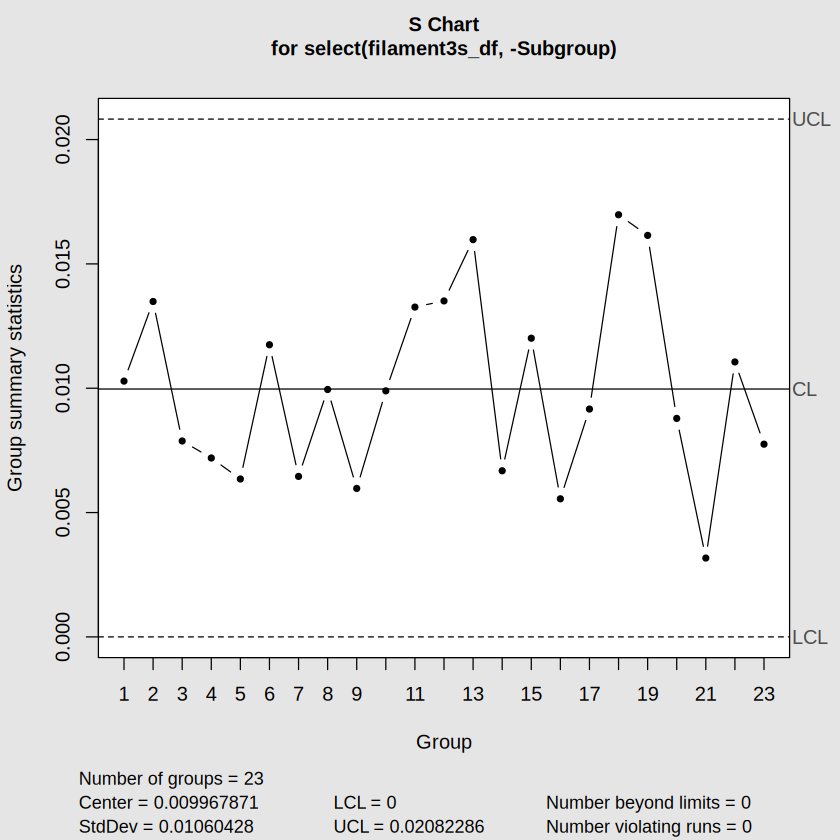

In [29]:
qcc(filament3s_df |> select(-`Subgroup`), type = "S", plot = TRUE)

### Q8: Using your final Phase I estimates of the process mean and process standard deviation (using $s$ method), perform a process capability analysis against the specification limits given about. Report and interpret $FNC$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?


Process Capability Analysis

Call:
process.capability(object = phase1_xbar3s, spec.limits = c(1.7,     1.8), target = 1.75, nsigmas = 3)

Number of obs = 115          Target = 1.75
       Center = 1.751           LSL = 1.7
       StdDev = 0.0108          USL = 1.8

Capability indices:

      Value   2.5%  97.5%
Cp    1.544  1.343  1.743
Cp_l  1.587  1.406  1.767
Cp_u  1.501  1.329  1.672
Cp_k  1.501  1.296  1.705
Cpm   1.531  1.332  1.730

Exp<LSL 0%	 Obs<LSL 0%
Exp>USL 0%	 Obs>USL 0%


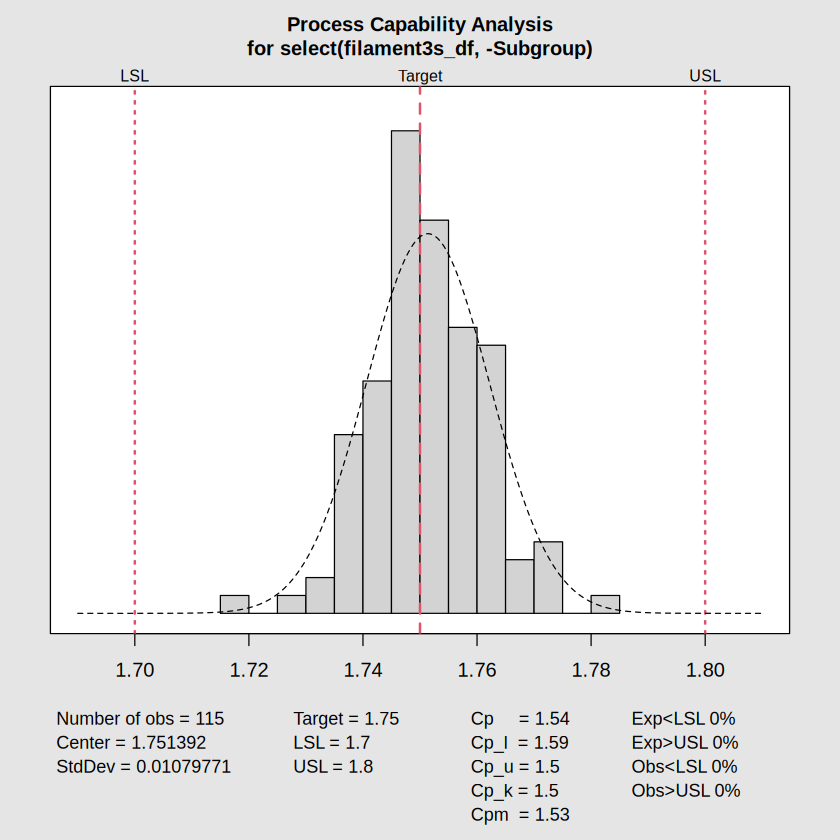

In [30]:
## Q8 Code ##

## Cp ##

process.capability(phase1_xbar3s,spec.limits=c(1.7,1.8),target=1.75,nsigmas=3)

#the LSL and USL values are coming directly from the inital prompt question.
#The Target value of 1.75 is also coming from there


|  | Value | 2.5% | 97.5% level |
|---|---| ---| ---|
| CP | 1.54 |1.343| 1.743|
| CP_1 | 1.59 |1.406 | 1.767|
| CP_u | 1.5 | 1.329| 1.672|
| CP_k | 1.5 | 1.296| 1.705|
| Cpm | 1.53 | 1.332| 1.730

## FNC ##
From the chart, ExpUSL = 0% = 0. This is good.

This is well centered due to Cp = 1.544 and CPk = 1.501. Since these values are very closes, this indicates that there is minimal off centering.

The process is capabale.

## Improve

### Q9: Briefly provide a contextual explanation as to leaving OOC points in the Phase I calculation of the control limits after identifying an assignable cause is not advisable.

Once an assignable cause has been identified for an out-of-control point, that point should be removed and the limits recalculated.

## Control

### Q10: Read in the Phase II data into R. Using the finalized Phase I center line and control limits from Q7, construct the Phase II $\bar{X}$ chart. Do any subgroups plot outside the control limits?

In [34]:
## Q10 Code ##

## Read in Phase II data ##

FilamentDiameter_PhaseII <- read_xlsx("FilamentDiameter_PhaseII.xlsx")

## Save the Phase I limits and center values ##
## Limits ##

xbar_lims <- phase1_xbar3s$limits

## Center Values ##

xbar_center <- phase1_xbar3s$center


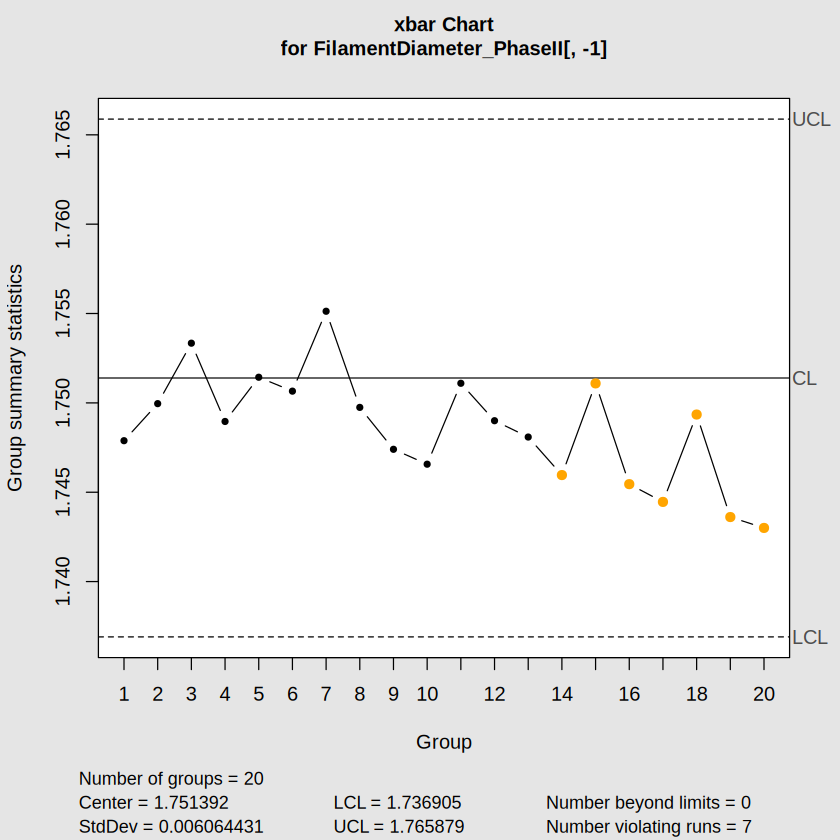

In [37]:

## Phase II X-bar ##

phase2_xbar <- qcc(FilamentDiameter_PhaseII[,-1],
    type="xbar",
    center=xbar_center,
    limits=xbar_lims,
    plot=TRUE)

In [38]:
phase2_xbar$violations$violating.runs

[1] 14 15 16 17 18 19 20

There is seven violating runs. Tthe pattern as a whole is highly unlikely under a stable, in-control process. Runs like this can signal a systematic shift in the process that the control limits alone wouldn't catch.

The drift is indicating that the filament is getting thinner.This could be due to the heating element needing a replacement soon

### Q11: Construct a Phase II $s$ chart. Do any subgroups plot outside the control limits?

List of 11
 $ call      : language qcc(data = FilamentDiameter_PhaseII[, -1], type = "S", center = s_center,      limits = s_lims, plot = TRUE)
 $ type      : chr "S"
 $ data.name : chr "FilamentDiameter_PhaseII[, -1]"
 $ data      : num [1:20, 1:5] 1.74 1.75 1.76 1.75 1.75 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:20] 0.00989 0.00292 0.00445 0.00625 0.00177 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes     : int [1:20] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 0.00587
 $ std.dev   : num 0.00625
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 0 0.0123
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

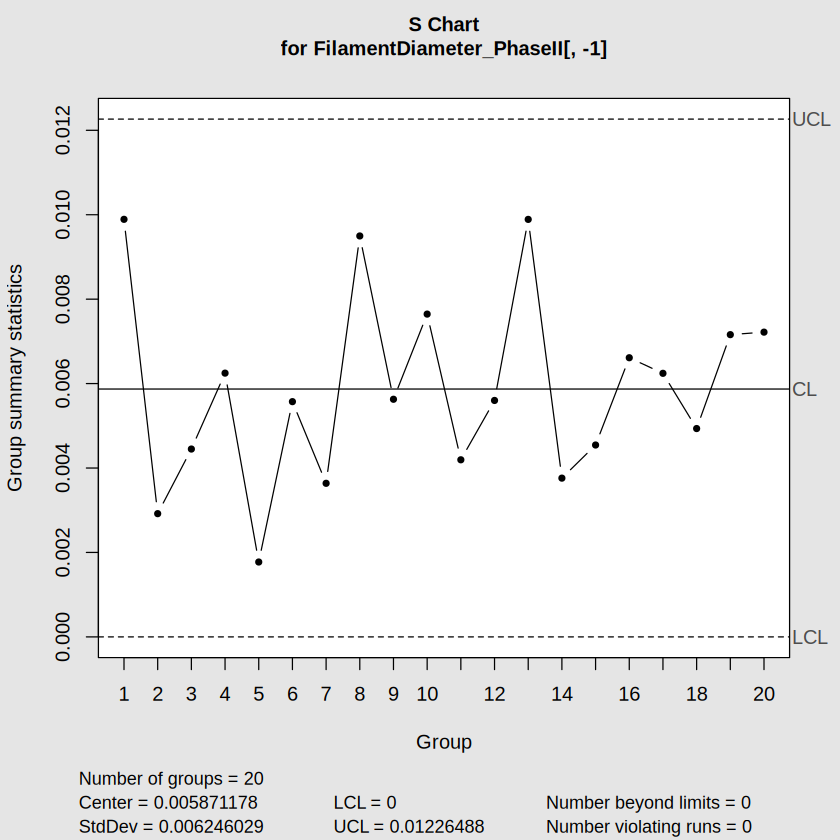

In [39]:
## Q11 Code ##

## Phase II S ##

qcc(FilamentDiameter_PhaseII[,-1],
    type="S",
    center=s_center,
    limits=s_lims,
    plot=TRUE)

## So we have evidence that the mean has shifted, but not the variance ##

No subgroups are plotting outside the control limits.

### Q12: Provide an overview of the results that the plant manager can provide the Vice President of Operations. Do they need to completely overhaul line 3 or is it salvagable?

In Phase 2, we noticed a downward trend. Due to this I would advise replacing the heating element on Line 3 now rather than at the 6 month mark.